In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import os
import seaborn as sns


In [2]:
#trial for one
tsv_dir = "/media/seungyun/8TBHardDisk1/proteomics/OUT/out_K4b_DDAplus3/"  #directory path with file
RAS = pd.read_csv(tsv_dir+'combined_protein_label_quant.tsv',sep='\t')
G12V_WT_HNTL_raw = RAS.iloc[:,[0,1,2,3,4,5,9,13,17,21,25]]
G12V_WT_LNTH_raw  =  RAS.iloc[:,[0,1,2,3,4,6,10,14,18,22,26]]
RAS_WT_HNTL_raw = RAS.iloc[:,[0,1,2,3,4,7,11,15,19,23,27]]
RAS_WT_LNTH_raw= RAS.iloc[:,[0,1,2,3,4,8,12,16,20,24,28]]
'GD_HNTL', 'GD_LNTH', 'WT_HNTL', 'WT_LNTH'
RAS_WT_LNTH = RAS_WT_LNTH_raw.loc[(RAS_WT_LNTH_raw.iloc[:, 5] != 0) & (RAS_WT_HNTL_raw.iloc[:, 6] != 0),:]
RAS_WT_HNTL = RAS_WT_HNTL_raw.loc[(RAS_WT_HNTL_raw.iloc[:, 5] != 0) & (RAS_WT_HNTL_raw.iloc[:, 6] != 0),:]
WT_HLratio_LNTH = RAS_WT_LNTH.iloc[:,[1,9]]
WT_HLratio_HNTL = RAS_WT_HNTL.iloc[:,[1,9]]

condition_heavy_only = (RAS_WT_HNTL_raw.iloc[:, 6] > 1) & ((RAS_WT_HNTL_raw.iloc[:, 5]  == 0) | (RAS_WT_HNTL_raw.iloc[:, 5].isna()))
condition_light_only = (RAS_WT_HNTL_raw.iloc[:, 5] > 1) & ((RAS_WT_HNTL_raw.iloc[:, 6]== 0) | (RAS_WT_HNTL_raw.iloc[:, 6].isna()))

WT_HLratio_HNTL[condition_heavy_only,9] = 100
WT_HLratio_HNTL[condition_light_only,9] = 0

condition_heavy_only = (RAS_WT_LNTH_raw.iloc[:, 6] > 1) & ((RAS_WT_LNTH_raw.iloc[:, 5]  == 0) | (RAS_WT_HNTL_raw.iloc[:, 5].isna()))
condition_light_only = (RAS_WT_LNTH_raw.iloc[:, 5] > 1) & ((RAS_WT_LNTH_raw.iloc[:, 6]== 0) | (RAS_WT_HNTL_raw.iloc[:, 6].isna()))

WT_HLratio_LNTH[condition_heavy_only,9] = 100
WT_HLratio_LNTH[condition_light_only,9] = 0


WT_HLratio_HNTL.set_index("Protein ID")
WT_HLratio_LNTH.set_index("Protein ID")
RAS_WT = pd.merge(WT_HLratio_LNTH,WT_HLratio_HNTL, how='inner', on='Protein ID') 

col = RAS_WT.columns
RAS_WT = RAS_WT.sort_values(col[1],ascending=False)

# Load your data
df = RAS_WT

# Assuming your CSV has columns named like 'Forward' and 'Reverse'
# If they have different names, please tell me!

# Create a column for sample number
df['Sample_Number'] = range(1, len(df) + 1)

# Plot
plt.figure(figsize=(8, 6))

# Plot Forward
plt.scatter(df['Sample_Number'], df[col[1]], color='blue', label='Forward')

# Plot Reverse
plt.scatter(df['Sample_Number'], df[col[2]], color='red', label='Reverse')

plt.xlabel('Protein number')
plt.ylabel('Heavy/Light ratio')
plt.title('Heavy/Light ratio for Forward and Reverse')
plt.yscale('log')  # optional, since your example plot looks like log scale
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


TypeError: unhashable type: 'Series'

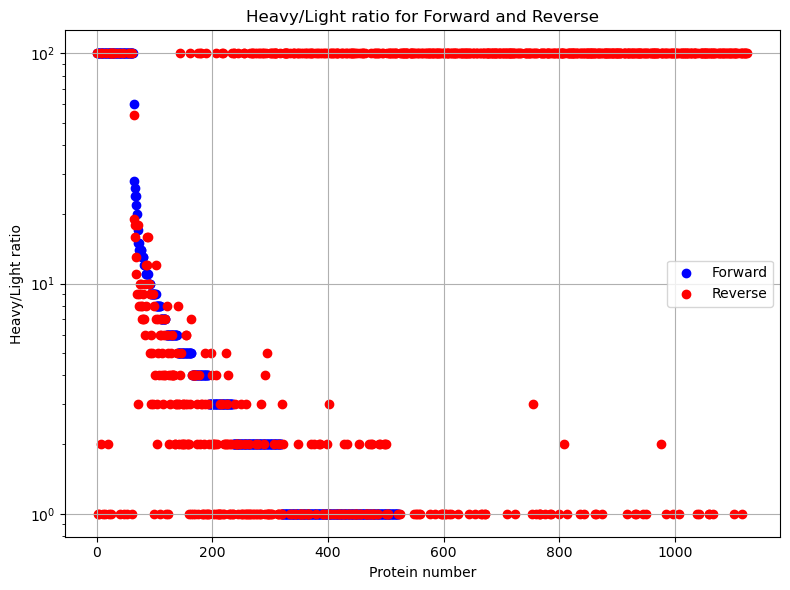

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the TSV file
tsv_dir = "/media/seungyun/8TBHardDisk1/proteomics/OUT/out_K4b_DDAplus3/"
RAS = pd.read_csv(tsv_dir + 'combined_protein_label_quant.tsv', sep='\t')

# Extract relevant columns
RAS_WT_LNTH_raw = RAS.iloc[:, [0, 1, 2, 3, 4, 5, 9, 13, 17, 21, 25]]
RAS_WT_HNTL_raw = RAS.iloc[:, [0, 1, 2, 3, 4, 6, 10, 14, 18, 22, 26]]

# Remove proteins where both Heavy and Light are zero
RAS_WT_LNTH = RAS_WT_LNTH_raw.loc[(RAS_WT_LNTH_raw.iloc[:, 5] != 0) & (RAS_WT_LNTH_raw.iloc[:, 6] != 0), :]
RAS_WT_HNTL = RAS_WT_HNTL_raw.loc[(RAS_WT_HNTL_raw.iloc[:, 5] != 0) & (RAS_WT_HNTL_raw.iloc[:, 6] != 0), :]

# Prepare Forward and Reverse tables
WT_HLratio_LNTH = RAS_WT_LNTH.iloc[:, [1, 9]].copy()  # [Protein ID, H/L ratio]
WT_HLratio_HNTL = RAS_WT_HNTL.iloc[:, [1, 9]].copy()

# --- Modify H/L ratio based on heavy-only or light-only detection ---

# For Reverse (HNTL)
heavy = RAS_WT_HNTL_raw.iloc[:, 5]
light = RAS_WT_HNTL_raw.iloc[:, 6]

condition_heavy_only = (heavy > 1) & ((light == 0) | (light.isna()))
condition_light_only = (light > 1) & ((heavy == 0) | (heavy.isna()))

WT_HLratio_HNTL.loc[condition_heavy_only, WT_HLratio_HNTL.columns[1]] = 100
WT_HLratio_HNTL.loc[condition_light_only, WT_HLratio_HNTL.columns[1]] = 0

# For Forward (LNTH)
heavy = RAS_WT_LNTH_raw.iloc[:, 5]
light = RAS_WT_LNTH_raw.iloc[:, 6]

condition_heavy_only = (heavy > 1) & ((light == 0) | (light.isna()))
condition_light_only = (light > 1) & ((heavy == 0) | (heavy.isna()))

WT_HLratio_LNTH.loc[condition_heavy_only, WT_HLratio_LNTH.columns[1]] = 100
WT_HLratio_LNTH.loc[condition_light_only, WT_HLratio_LNTH.columns[1]] = 0

# --- Merge Forward and Reverse ---
RAS_WT = pd.merge(WT_HLratio_LNTH, WT_HLratio_HNTL, how='inner', on='Protein ID', suffixes=('_Forward', '_Reverse'))

# Sort by Forward ratio
col = RAS_WT.columns
RAS_WT = RAS_WT.sort_values(col[1], ascending=False)

# Create a column for sample number
RAS_WT['Sample_Number'] = range(1, len(RAS_WT) + 1)

# --- Plot ---
plt.figure(figsize=(8, 6))

# Plot Forward
plt.scatter(RAS_WT['Sample_Number'], RAS_WT[col[1]], color='blue', label='Forward')

# Plot Reverse
plt.scatter(RAS_WT['Sample_Number'], RAS_WT[col[2]], color='red', label='Reverse')

plt.xlabel('Protein number')
plt.ylabel('Heavy/Light ratio')
plt.title('Heavy/Light ratio for Forward and Reverse')
plt.yscale('log')  # optional, comment out if you don't want log
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [32]:
RAS_WT.head()

,Protein ID,SethMiller10360343_HRasHeavyFlagLightNT Ratios HL,SethMiller10360343_HRasHeavyNTLightFlag Ratios HL,Sample_Number
929,Q92620,100,0,1
1021,Q9BVS4,100,0,2
221,P08779,100,100,3
788,Q5D862,100,100,4
467,P51532,100,0,5


/tmp/ipykernel_2476934/3051161737.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  RAS_WT_LNTH_raw['H/L_Ratio'] = process_HL_ratio(RAS_WT_LNTH_raw, 5, 6)
/tmp/ipykernel_2476934/3051161737.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  RAS_WT_HNTL_raw['H/L_Ratio'] = process_HL_ratio(RAS_WT_HNTL_raw, 5, 6)


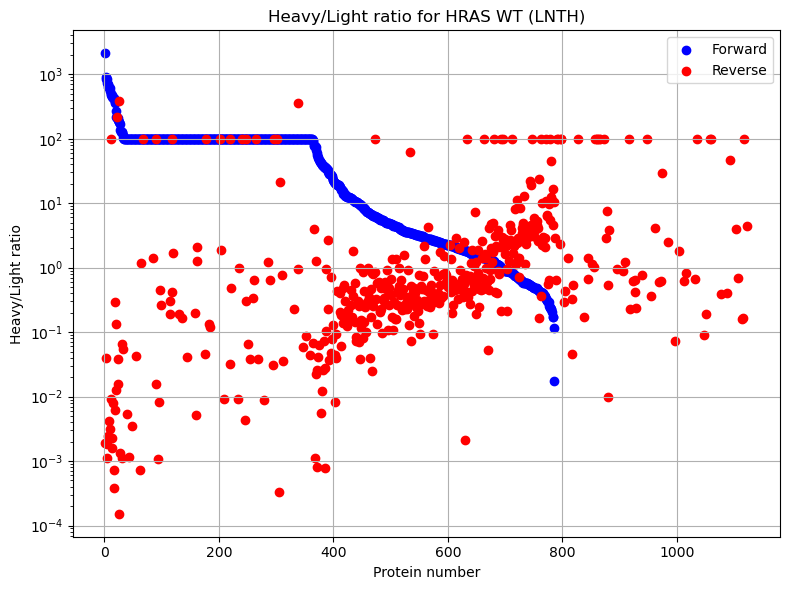

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Set your directory and load file
tsv_dir = "/media/seungyun/8TBHardDisk1/proteomics/OUT/out_K4b_DDAplus3/"
RAS = pd.read_csv(tsv_dir + 'combined_protein_label_quant.tsv', sep='\t')

# Select raw data for each condition
G12V_WT_HNTL_raw = RAS.iloc[:,[0,1,2,3,4,5,9,13,17,21,25]]
G12V_WT_LNTH_raw  =  RAS.iloc[:,[0,1,2,3,4,6,10,14,18,22,26]]
RAS_WT_HNTL_raw = RAS.iloc[:,[0,1,2,3,4,7,11,15,19,23,27]]
RAS_WT_LNTH_raw= RAS.iloc[:,[0,1,2,3,4,8,12,16,20,24,28]]
# Apply the missing value handling (100 if heavy > 1 & light missing, 0 if light > 1 & heavy missing)
def process_HL_ratio(df, heavy_col, light_col):
    heavy = df.iloc[:, heavy_col]
    light = df.iloc[:, light_col]
    ratio = heavy / light

    # Conditions
    condition_heavy_only = (heavy > 1) & ((light == 0) | (light.isna()))
    condition_light_only = (light > 1) & ((heavy == 0) | (heavy.isna()))

    ratio[condition_heavy_only] = 100
    ratio[condition_light_only] = 0

    return ratio

# Process each set
RAS_WT_LNTH_raw['H/L_Ratio'] = process_HL_ratio(RAS_WT_LNTH_raw, 5, 6)
RAS_WT_HNTL_raw['H/L_Ratio'] = process_HL_ratio(RAS_WT_HNTL_raw, 5, 6)

# Keep Protein ID and H/L ratio
WT_HLratio_LNTH = RAS_WT_LNTH_raw[['Protein ID', 'H/L_Ratio']]
WT_HLratio_HNTL = RAS_WT_HNTL_raw[['Protein ID', 'H/L_Ratio']]

# Merge Forward and Reverse
RAS_WT = pd.merge(WT_HLratio_LNTH, WT_HLratio_HNTL, how='inner', on='Protein ID', suffixes=('_Forward', '_Reverse'))

# Sort by Forward ratio
RAS_WT = RAS_WT.sort_values('H/L_Ratio_Forward', ascending=False)

# Add sample number
RAS_WT['Sample_Number'] = range(1, len(RAS_WT) + 1)

# Plot
plt.figure(figsize=(8, 6))

plt.scatter(RAS_WT['Sample_Number'], RAS_WT['H/L_Ratio_Forward'], color='blue', label='Forward')
plt.scatter(RAS_WT['Sample_Number'], RAS_WT['H/L_Ratio_Reverse'], color='red', label='Reverse')

plt.xlabel('Protein number')
plt.ylabel('Heavy/Light ratio')
plt.title('Heavy/Light ratio for HRAS WT (LNTH)')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2476934/3019190845.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  RAS_WT_LNTH_raw['H/L_Ratio'] = process_HL_ratio(RAS_WT_LNTH_raw, 5, 6)
/tmp/ipykernel_2476934/3019190845.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  RAS_WT_HNTL_raw['H/L_Ratio'] = process_HL_ratio(RAS_WT_HNTL_raw, 5, 6)
/tmp/ipykernel_2476934/3019190845.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See th

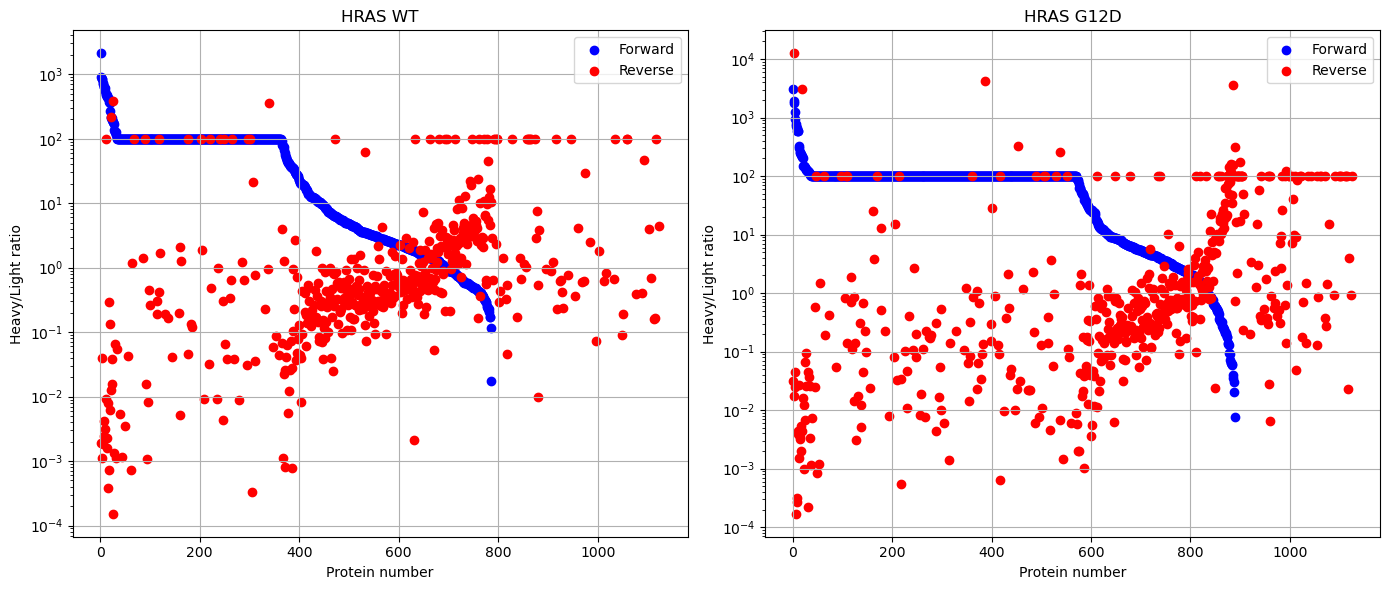

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Set your directory and load file
tsv_dir = "/media/seungyun/8TBHardDisk1/proteomics/OUT/out_K4b_DDAplus3/"
RAS = pd.read_csv(tsv_dir + 'combined_protein_label_quant.tsv', sep='\t')

# Select raw data for each condition
G12D_WT_HNTL_raw = RAS.iloc[:,[0,1,2,3,4,5,9,13,17,21,25]]
G12D_WT_LNTH_raw  =  RAS.iloc[:,[0,1,2,3,4,6,10,14,18,22,26]]
RAS_WT_HNTL_raw = RAS.iloc[:,[0,1,2,3,4,7,11,15,19,23,27]]
RAS_WT_LNTH_raw= RAS.iloc[:,[0,1,2,3,4,8,12,16,20,24,28]]

# Define function to process H/L ratio
def process_HL_ratio(df, heavy_col, light_col):
    heavy = df.iloc[:, heavy_col]
    light = df.iloc[:, light_col]
    ratio = heavy / light

    # Handle missing values
    condition_heavy_only = (heavy > 1) & ((light == 0) | (light.isna()))
    condition_light_only = (light > 1) & ((heavy == 0) | (heavy.isna()))

    ratio[condition_heavy_only] = 100
    ratio[condition_light_only] = 0

    return ratio

# Process H/L ratio
RAS_WT_LNTH_raw['H/L_Ratio'] = process_HL_ratio(RAS_WT_LNTH_raw, 5, 6)
RAS_WT_HNTL_raw['H/L_Ratio'] = process_HL_ratio(RAS_WT_HNTL_raw, 5, 6)
G12D_WT_LNTH_raw['H/L_Ratio'] = process_HL_ratio(G12D_WT_LNTH_raw, 5, 6)
G12D_WT_HNTL_raw['H/L_Ratio'] = process_HL_ratio(G12D_WT_HNTL_raw, 5, 6)

# Merge Forward and Reverse for each condition
RAS_WT = pd.merge(
    RAS_WT_LNTH_raw[['Protein ID', 'H/L_Ratio']],
    RAS_WT_HNTL_raw[['Protein ID', 'H/L_Ratio']],
    how='inner', on='Protein ID', suffixes=('_Forward', '_Reverse')
)

RAS_G12D = pd.merge(
    G12D_WT_LNTH_raw[['Protein ID', 'H/L_Ratio']],
    G12D_WT_HNTL_raw[['Protein ID', 'H/L_Ratio']],
    how='inner', on='Protein ID', suffixes=('_Forward', '_Reverse')
)

# Sort by Forward ratio
RAS_WT = RAS_WT.sort_values('H/L_Ratio_Forward', ascending=False)
RAS_G12D = RAS_G12D.sort_values('H/L_Ratio_Forward', ascending=False)

# Add sample number
RAS_WT['Sample_Number'] = range(1, len(RAS_WT) + 1)
RAS_G12D['Sample_Number'] = range(1, len(RAS_G12D) + 1)

# Plot side-by-side
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Plot HRAS WT
axs[0].scatter(RAS_WT['Sample_Number'], RAS_WT['H/L_Ratio_Forward'], color='blue', label='Forward')
axs[0].scatter(RAS_WT['Sample_Number'], RAS_WT['H/L_Ratio_Reverse'], color='red', label='Reverse')
axs[0].set_xlabel('Protein number')
axs[0].set_ylabel('Heavy/Light ratio')
axs[0].set_title('HRAS WT')
axs[0].set_yscale('log')
axs[0].legend()
axs[0].grid(True)

# Plot HRAS G12D
axs[1].scatter(RAS_G12D['Sample_Number'], RAS_G12D['H/L_Ratio_Forward'], color='blue', label='Forward')
axs[1].scatter(RAS_G12D['Sample_Number'], RAS_G12D['H/L_Ratio_Reverse'], color='red', label='Reverse')
axs[1].set_xlabel('Protein number')
axs[1].set_ylabel('Heavy/Light ratio')
axs[1].set_title('HRAS G12D')
axs[1].set_yscale('log')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2476934/3961033525.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hl[condition_heavy_only] = 100
/tmp/ipykernel_2476934/3961033525.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hl[condition_light_only] = 0
/tmp/ipykernel_2476934/3961033525.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hl[condition_heavy_only] = 100
/tmp/ipykernel_2476934/3961033525.py:30: SettingWithCopyWarning: 
A value is trying to 

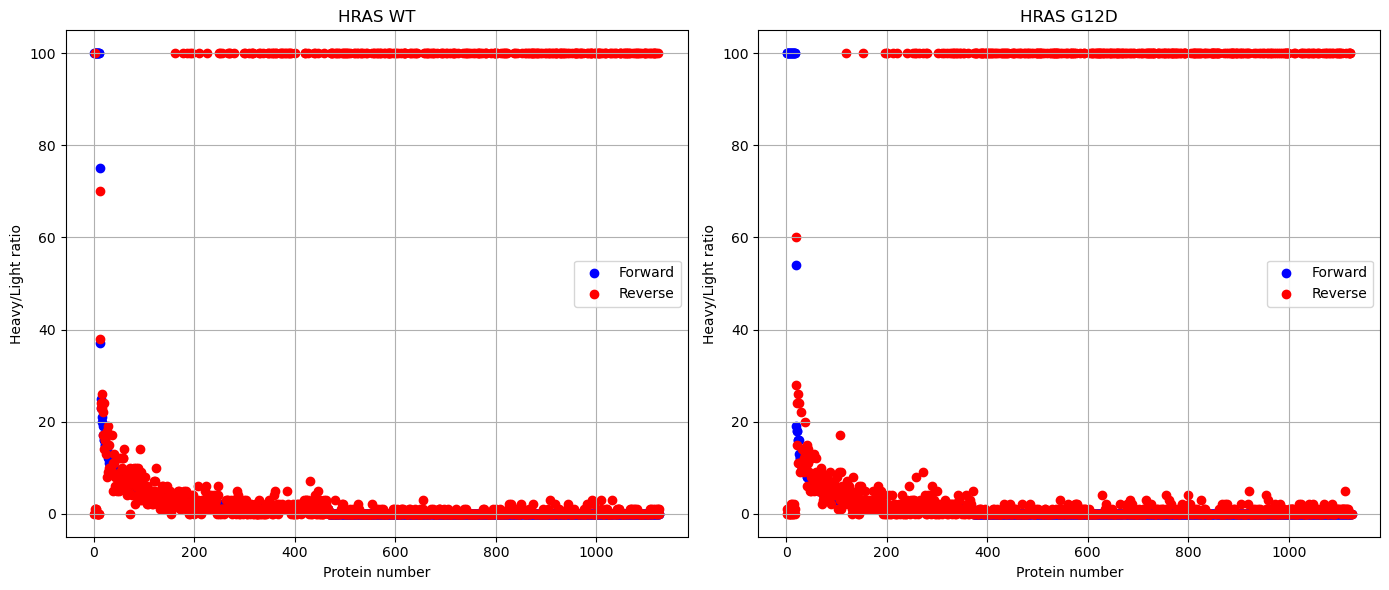

In [21]:
# Load the TSV
tsv_dir = "/media/seungyun/8TBHardDisk1/proteomics/OUT/out_K4b_DDAplus3/"
RAS = pd.read_csv(tsv_dir + 'combined_protein_label_quant.tsv', sep='\t')

# Now select directly the H/L ratio columns (21–24) and intensities (5–8)
G12D_WT_HNTL_raw = RAS.iloc[:,[0,1,2,3,4,5,9,13,17,21,25]]
G12D_WT_LNTH_raw  =  RAS.iloc[:,[0,1,2,3,4,6,10,14,18,22,26]]
RAS_WT_HNTL_raw = RAS.iloc[:,[0,1,2,3,4,7,11,15,19,23,27]]
RAS_WT_LNTH_raw= RAS.iloc[:,[0,1,2,3,4,8,12,16,20,24,28]]


# Function to adjust existing HL ratio
def adjust_existing_HL(df, light_idx, heavy_idx, hl_idx):
    heavy = df.iloc[:, heavy_idx]
    light = df.iloc[:, light_idx]
    hl = df.iloc[:, hl_idx]

    # Remove rows where both heavy and light are zero or missing
    valid = ~((heavy == 0) & (light == 0))
    df = df[valid]
    heavy = df.iloc[:, heavy_idx]
    light = df.iloc[:, light_idx]
    hl = df.iloc[:, hl_idx]

    # Adjust conditions
    condition_heavy_only = (heavy > 1) & ((light == 0) | (light.isna()))
    condition_light_only = (light > 1) & ((heavy == 0) | (heavy.isna()))

    hl[condition_heavy_only] = 100
    hl[condition_light_only] = 0

    return df[['Protein ID']].assign(HL_ratio=hl)

# Adjust for each sample
WT_LNTH = adjust_existing_HL(RAS_WT_LNTH_raw, 5, 6, 9)   # heavy, light, HL columns
WT_HNTL = adjust_existing_HL(RAS_WT_HNTL_raw, 5, 6, 9)
G12D_LNTH = adjust_existing_HL(G12D_WT_LNTH_raw, 5, 6, 9)
G12D_HNTL = adjust_existing_HL(G12D_WT_HNTL_raw, 5, 6, 9)

# Merge forward and reverse
RAS_WT = pd.merge(WT_LNTH, WT_HNTL, how='inner', on='Protein ID', suffixes=('_Forward', '_Reverse'))
RAS_G12D = pd.merge(G12D_LNTH, G12D_HNTL, how='inner', on='Protein ID', suffixes=('_Forward', '_Reverse'))

# Sort by Forward ratio
RAS_WT = RAS_WT.sort_values('HL_ratio_Forward', ascending=False)
RAS_G12D = RAS_G12D.sort_values('HL_ratio_Forward', ascending=False)

# Add sample numbers
RAS_WT['Sample_Number'] = range(1, len(RAS_WT) + 1)
RAS_G12D['Sample_Number'] = range(1, len(RAS_G12D) + 1)

# Plot side-by-side
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# HRAS WT
axs[0].scatter(RAS_WT['Sample_Number'], RAS_WT['HL_ratio_Forward'], color='blue', label='Forward')
axs[0].scatter(RAS_WT['Sample_Number'], RAS_WT['HL_ratio_Reverse'], color='red', label='Reverse')
axs[0].set_xlabel('Protein number')
axs[0].set_ylabel('Heavy/Light ratio')
axs[0].set_title('HRAS WT')
axs[0].legend()
axs[0].grid(True)

# HRAS G12D
axs[1].scatter(RAS_G12D['Sample_Number'], RAS_G12D['HL_ratio_Forward'], color='blue', label='Forward')
axs[1].scatter(RAS_G12D['Sample_Number'], RAS_G12D['HL_ratio_Reverse'], color='red', label='Reverse')
axs[1].set_xlabel('Protein number')
axs[1].set_ylabel('Heavy/Light ratio')
axs[1].set_title('HRAS G12D')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

In [10]:
# Condition
condition = (RAS_WT['HL_ratio_Forward'] > 1.5) & (RAS_WT['HL_ratio_Reverse'] < 0.67)

# Count proteins
num_proteins = condition.sum()


print(f"Number of proteins satisfying the condition: {num_proteins}")

condition_G12D = (RAS_G12D['HL_ratio_Forward'] > 1.5) & (RAS_G12D['HL_ratio_Reverse'] < 0.67)
num_G12D = condition_G12D.sum()
print(f"HRAS G12D: {num_G12D} proteins pass the filter.")

Number of proteins satisfying the condition: 15
HRAS G12D: 13 proteins pass the filter.


In [12]:
RAS_WT.head()

,Protein ID,HL_ratio_Forward,HL_ratio_Reverse,Sample_Number
551,Q07955,100,0,1
1075,Q9Y2P8,100,100,2
817,Q92841,100,1,3
627,Q15233,100,1,4
628,Q15287,100,1,5


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# Step 1: Load data
tsv_dir = "/media/seungyun/8TBHardDisk1/proteomics/OUT/out_K4b_DDAplus3/"
RAS = pd.read_csv(tsv_dir + 'combined_protein_label_quant.tsv', sep='\t')

# Split datasets
G12D_HNTL_raw = RAS.iloc[:, [1, 5, 9, 13, 17, 21, 25]].copy()
G12D_LNTH_raw = RAS.iloc[:, [1, 6, 10, 14, 18, 22, 26]].copy()
WT_HNTL_raw = RAS.iloc[:, [1, 7, 11, 15, 19, 23, 27]].copy()
WT_LNTH_raw = RAS.iloc[:, [1, 8, 12, 16, 20, 24, 28]].copy()

# Step 2: Drop rows where both Light and Heavy are zero or NaN
def drop_zero_heavy_light(df):
    light = df.iloc[:, 1]
    heavy = df.iloc[:, 2]
    return df.loc[~((light == 0) & (heavy == 0)) & ~(light.isna() & heavy.isna()), :]

WT_LNTH = drop_zero_heavy_light(WT_LNTH_raw).fillna(0)
WT_HNTL = drop_zero_heavy_light(WT_HNTL_raw).fillna(0)
G12D_LNTH = drop_zero_heavy_light(G12D_LNTH_raw).fillna(0)
G12D_HNTL = drop_zero_heavy_light(G12D_HNTL_raw).fillna(0)

print(WT_LNTH)


      Protein ID  XiaoyuZhang10361797_SILAC_K4bWTFlagLNTH_1 Light Intensity  \
0     A0A075B6R9                                       6.111535e+07           
1     A0A075B6S2                                       9.824643e+09           
7         A6NIZ1                                       8.828374e+07           
10        E9PRG8                                       5.109092e+06           
11        O00139                                       3.749436e+06           
...          ...                                                ...           
1117      Q9Y676                                       1.927400e+07           
1120      Q9Y6D6                                       6.356189e+06           
1121      Q9Y6E2                                       5.236558e+07           
1123      Q9Y6K0                                       1.890456e+07           
1124      Q9Y6Y0                                       4.246236e+08           

      XiaoyuZhang10361797_SILAC_K4bWTFlagLNTH_1 Hea

Step 4 - Original data:
WT selected proteins: 47
G12D selected proteins: 36


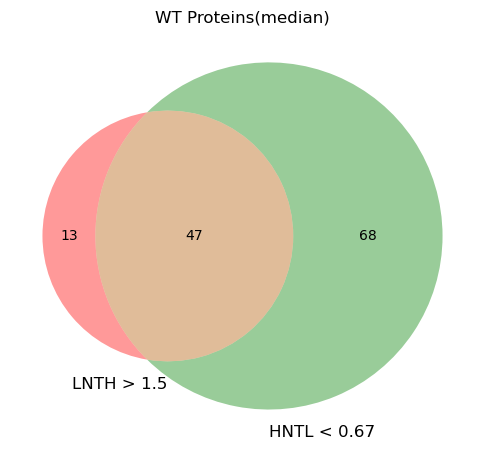

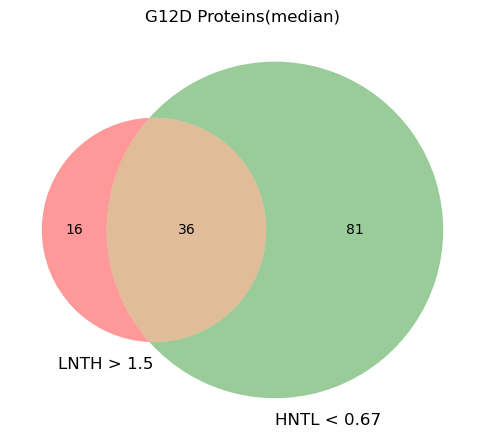


Step 6 - Adjusted data:
WT selected proteins (adjusted): 56
G12D selected proteins (adjusted): 56


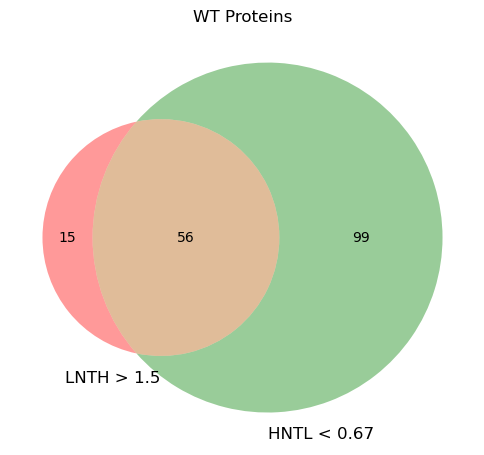

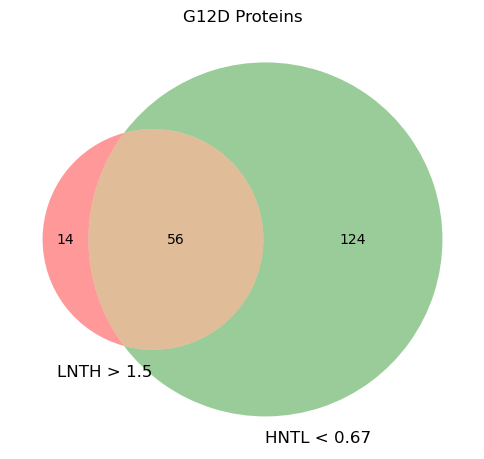

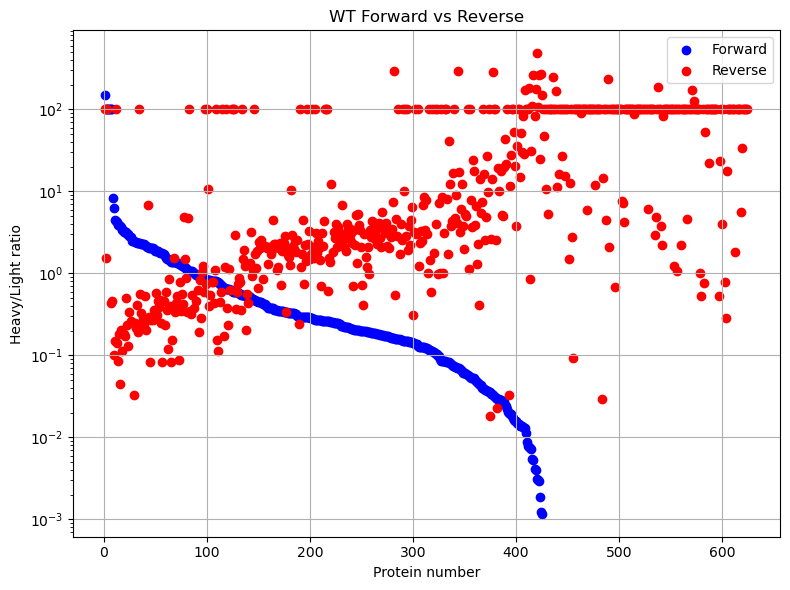

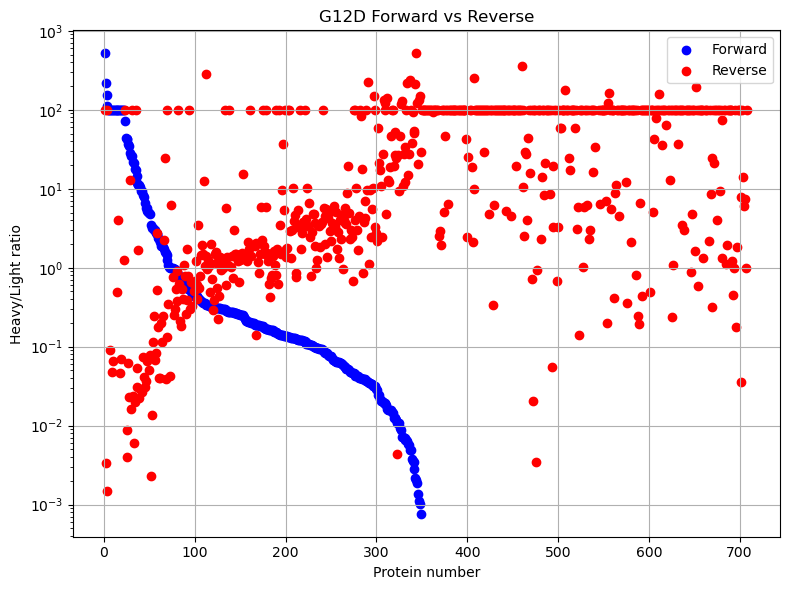

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# Step 1: Load data
tsv_dir = "/media/seungyun/8TBHardDisk1/proteomics/OUT/out_K4b_DDAplus3/"
RAS = pd.read_csv(tsv_dir + 'combined_protein_label_quant.tsv', sep='\t')

# Split datasets
G12D_HNTL_raw = RAS.iloc[:, [1, 5, 9, 13, 17, 21, 25]].copy()
G12D_LNTH_raw = RAS.iloc[:, [1, 6, 10, 14, 18, 22, 26]].copy()
WT_HNTL_raw = RAS.iloc[:, [1, 7, 11, 15, 19, 23, 27]].copy()
WT_LNTH_raw = RAS.iloc[:, [1, 8, 12, 16, 20, 24, 28]].copy()


# Step 2: Drop rows where both Light and Heavy are zero or NaN
def drop_zero_heavy_light(df):
    light = df.iloc[:, 1]
    heavy = df.iloc[:, 2]
    return df.loc[~((light == 0) & (heavy == 0)) & ~(light.isna() & heavy.isna()), :]

WT_LNTH = drop_zero_heavy_light(WT_LNTH_raw).fillna(0)
WT_HNTL = drop_zero_heavy_light(WT_HNTL_raw).fillna(0)
G12D_LNTH = drop_zero_heavy_light(G12D_LNTH_raw).fillna(0)
G12D_HNTL = drop_zero_heavy_light(G12D_HNTL_raw).fillna(0)



# Step 3: Add new column 'Median Ratios HL' by converting log2 ratios
def add_median_ratio(df):
    df['Median Ratios HL'] = 2 ** df.iloc[:, 6]  # Median Log2 Ratios HL is at 7th column (index 6)
    return df

WT_LNTH = add_median_ratio(WT_LNTH)
WT_HNTL = add_median_ratio(WT_HNTL)
G12D_LNTH = add_median_ratio(G12D_LNTH)
G12D_HNTL = add_median_ratio(G12D_HNTL)

# Step 4: Print number of proteins satisfying condition
def count_selected(df_LNTH, df_HNTL):
    cond = (df_LNTH['Median Ratios HL'] > 1.5) & (df_HNTL['Median Ratios HL'] < 0.67)
    return cond.sum()

print("Step 4 - Original data:")
print(f"WT selected proteins: {count_selected(WT_LNTH, WT_HNTL)}")
print(f"G12D selected proteins: {count_selected(G12D_LNTH, G12D_HNTL)}")

def venn_diagram(df_LNTH, df_HNTL, title):
    set_LNTH = set(df_LNTH.loc[df_LNTH['Median Ratios HL'] > 1.5, 'Protein ID'])
    set_HNTL = set(df_HNTL.loc[df_HNTL['Median Ratios HL'] < 0.67, 'Protein ID'])

    plt.figure(figsize=(6, 6))
    venn2([set_LNTH, set_HNTL], set_labels=('LNTH > 1.5', 'HNTL < 0.67'))
    plt.title(title)
    plt.show()

venn_diagram(WT_LNTH, WT_HNTL, "WT Proteins(median)")
venn_diagram(G12D_LNTH, G12D_HNTL, "G12D Proteins(median)")

# Step 5: Modify 'Median Ratios HL' based on heavy/light missing
def adjust_median_ratios(df):
    heavy = df.iloc[:, 2]
    light = df.iloc[:, 1]
    modified = df[['Protein ID', 'Median Ratios HL']].copy()

    condition_heavy_only = (heavy > 1) & ((light == 0) | (light.isna()))
    condition_light_only = (light > 1) & ((heavy == 0) | (heavy.isna()))

    modified.loc[condition_heavy_only, 'Median Ratios HL'] = 100
    modified.loc[condition_light_only, 'Median Ratios HL'] = 0

    return modified

WT_LNTH_adj = adjust_median_ratios(WT_LNTH)
WT_HNTL_adj = adjust_median_ratios(WT_HNTL)
G12D_LNTH_adj = adjust_median_ratios(G12D_LNTH)
G12D_HNTL_adj = adjust_median_ratios(G12D_HNTL)

# Step 6: Print number of proteins satisfying condition again
def count_selected_adj(df_LNTH, df_HNTL):
    cond = (df_LNTH['Median Ratios HL'] > 1.5) & (df_HNTL['Median Ratios HL'] < 0.67)
    return cond.sum()

print("\nStep 6 - Adjusted data:")
print(f"WT selected proteins (adjusted): {count_selected_adj(WT_LNTH_adj, WT_HNTL_adj)}")
print(f"G12D selected proteins (adjusted): {count_selected_adj(G12D_LNTH_adj, G12D_HNTL_adj)}")

# Step 7: Make Venn diagram



venn_diagram(WT_LNTH_adj, WT_HNTL_adj, "WT Proteins")
venn_diagram(G12D_LNTH_adj, G12D_HNTL_adj, "G12D Proteins")

# Step 8: Merge LNTH and HNTL
def merge_forward_reverse(df_LNTH, df_HNTL):
    df_LNTH = df_LNTH.set_index('Protein ID')
    df_HNTL = df_HNTL.set_index('Protein ID')
    merged = pd.merge(df_LNTH, df_HNTL, how='inner', left_index=True, right_index=True, suffixes=('_Forward', '_Reverse'))
    merged = merged.sort_values('Median Ratios HL_Forward', ascending=False)
    return merged

WT_merged = merge_forward_reverse(WT_LNTH_adj, WT_HNTL_adj)
G12D_merged = merge_forward_reverse(G12D_LNTH_adj, G12D_HNTL_adj)

# Step 9: Scatter plot
def scatter_plot(df, title):
    df['Sample_Number'] = range(1, len(df) + 1)

    plt.figure(figsize=(8, 6))
    plt.scatter(df['Sample_Number'], df['Median Ratios HL_Forward'], color='blue', label='Forward')
    plt.scatter(df['Sample_Number'], df['Median Ratios HL_Reverse'], color='red', label='Reverse')
    plt.xlabel('Protein number')
    plt.ylabel('Heavy/Light ratio')
    plt.title(title)
    plt.yscale('log')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

scatter_plot(WT_merged, "WT Forward vs Reverse")
scatter_plot(G12D_merged, "G12D Forward vs Reverse")


Step 4 - Original data:
WT selected proteins: 47
G12D selected proteins: 36


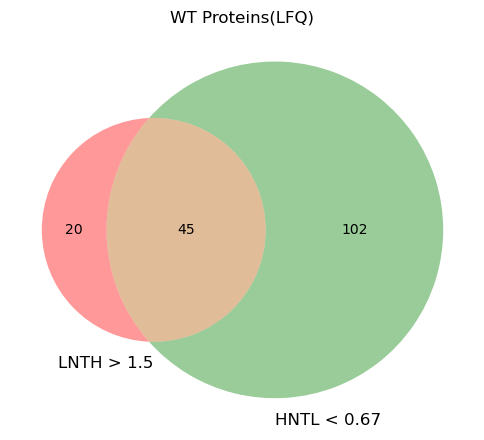

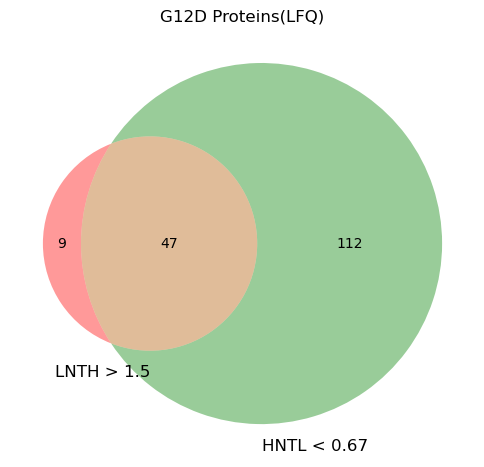


Step 6 - Adjusted data:
WT selected proteins (adjusted): 46
G12D selected proteins (adjusted): 49


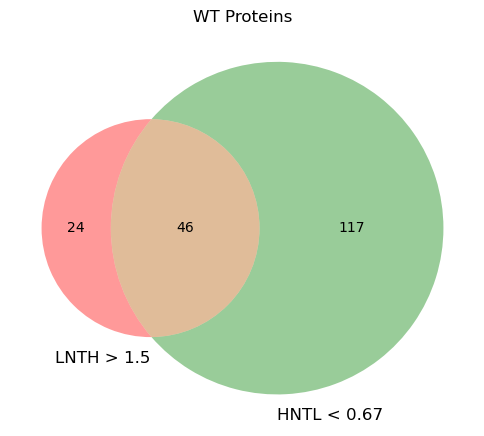

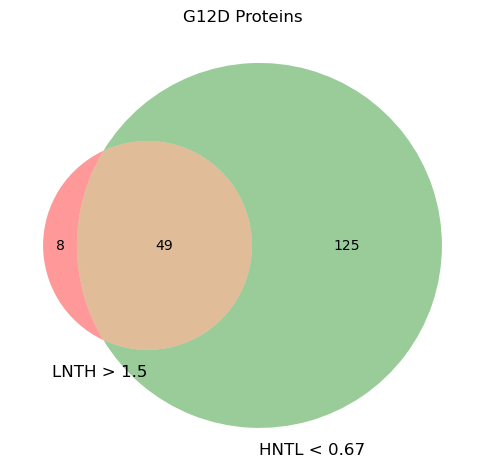

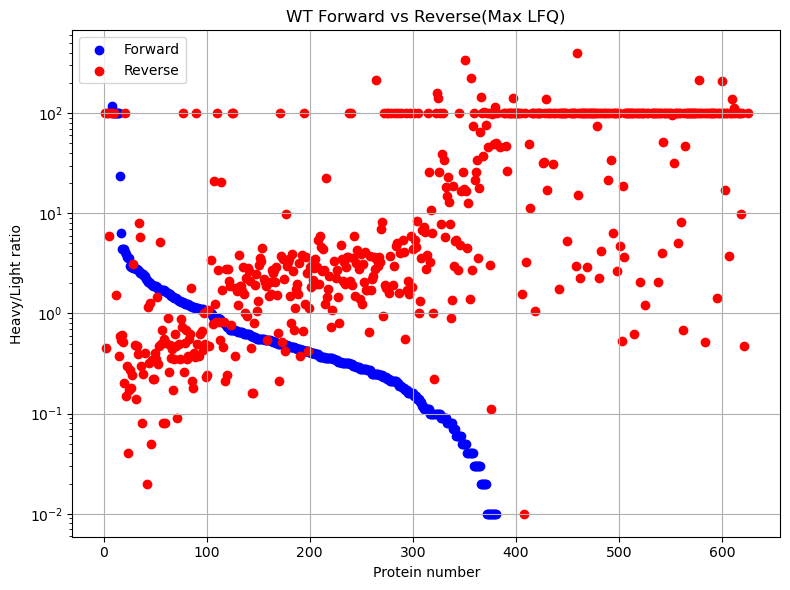

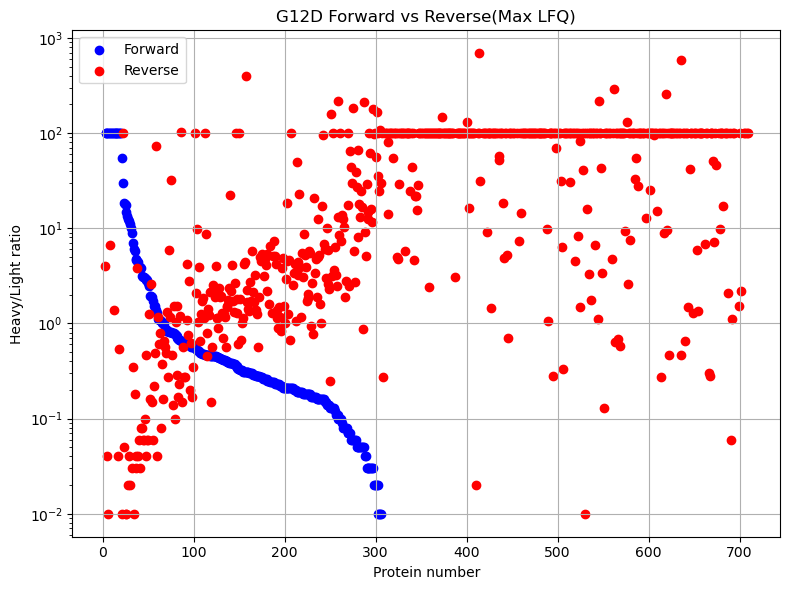

In [25]:
# Step 9: Add new column 'LFQ Ratios HL' by converting log2 ratios
def add_LFQ_ratio(df):
    df['LFQ Ratios HL'] =round(df.iloc[:, 4]/df.iloc[:, 3],2) # light LFQ is at 4th column (index 3)
    return df

WT_LNTH = add_LFQ_ratio(WT_LNTH)
WT_HNTL = add_LFQ_ratio(WT_HNTL)
G12D_LNTH = add_LFQ_ratio(G12D_LNTH)
G12D_HNTL = add_LFQ_ratio(G12D_HNTL)

# Step 10: Print number of proteins satisfying condition
def count_selected_LFQ(df_LNTH, df_HNTL):
    cond = (df_LNTH['LFQ Ratios HL'] > 1.5) & (df_HNTL['LFQ Ratios HL'] < 0.67)
    return cond.sum()

print("Step 4 - Original data:")
print(f"WT selected proteins: {count_selected_adj(WT_LNTH, WT_HNTL)}")
print(f"G12D selected proteins: {count_selected_adj(G12D_LNTH, G12D_HNTL)}")

def venn_diagram_LFQ(df_LNTH, df_HNTL, title):
    set_LNTH = set(df_LNTH.loc[df_LNTH['LFQ Ratios HL'] > 1.5, 'Protein ID'])
    set_HNTL = set(df_HNTL.loc[df_HNTL['LFQ Ratios HL'] < 0.67, 'Protein ID'])

    plt.figure(figsize=(6, 6))
    venn2([set_LNTH, set_HNTL], set_labels=('LNTH > 1.5', 'HNTL < 0.67'))
    plt.title(title)
    plt.show()

venn_diagram_LFQ(WT_LNTH, WT_HNTL, "WT Proteins(LFQ)")
venn_diagram_LFQ(G12D_LNTH, G12D_HNTL, "G12D Proteins(LFQ)")

# Step11: Modify 'LFQ Ratios HL' based on heavy/light missing
def adjust_median_ratios_LFQ(df):
    heavy = df.iloc[:, 2]
    light = df.iloc[:, 1]
    modified = df[['Protein ID', 'LFQ Ratios HL']].copy()

    condition_heavy_only = (heavy > 1) & ((light == 0) | (light.isna()))
    condition_light_only = (light > 1) & ((heavy == 0) | (heavy.isna()))

    modified.loc[condition_heavy_only, 'LFQ Ratios HL'] = 100
    modified.loc[condition_light_only, 'LFQ Ratios HL'] = 0

    return modified

WT_LNTH_adj = adjust_median_ratios_LFQ(WT_LNTH)
WT_HNTL_adj = adjust_median_ratios_LFQ(WT_HNTL)
G12D_LNTH_adj = adjust_median_ratios_LFQ(G12D_LNTH)
G12D_HNTL_adj = adjust_median_ratios_LFQ(G12D_HNTL)

# Step 12: Print number of proteins satisfying condition again
def count_selected_adj_LFQ(df_LNTH, df_HNTL):
    cond = (df_LNTH['LFQ Ratios HL'] > 1.5) & (df_HNTL['LFQ Ratios HL'] < 0.67)
    return cond.sum()

print("\nStep 6 - Adjusted data:")
print(f"WT selected proteins (adjusted): {count_selected_adj_LFQ(WT_LNTH_adj, WT_HNTL_adj)}")
print(f"G12D selected proteins (adjusted): {count_selected_adj_LFQ(G12D_LNTH_adj, G12D_HNTL_adj)}")

# Step 13: Make Venn diagram



venn_diagram_LFQ(WT_LNTH_adj, WT_HNTL_adj, "WT Proteins")
venn_diagram_LFQ(G12D_LNTH_adj, G12D_HNTL_adj, "G12D Proteins")

# Step 14: Merge LNTH and HNTL
def merge_forward_reverse_LFQ(df_LNTH, df_HNTL):
    df_LNTH = df_LNTH.set_index('Protein ID')
    df_HNTL = df_HNTL.set_index('Protein ID')
    merged = pd.merge(df_LNTH, df_HNTL, how='inner', left_index=True, right_index=True, suffixes=('_Forward', '_Reverse'))
    merged = merged.sort_values('LFQ Ratios HL_Forward', ascending=False)
    return merged

WT_merged = merge_forward_reverse_LFQ(WT_LNTH_adj, WT_HNTL_adj)
G12D_merged = merge_forward_reverse_LFQ(G12D_LNTH_adj, G12D_HNTL_adj)

# Step 15: Scatter plot
def scatter_plot_LFQ(df, title):
    df['Sample_Number'] = range(1, len(df) + 1)

    plt.figure(figsize=(8, 6))
    plt.scatter(df['Sample_Number'], df['LFQ Ratios HL_Forward'], color='blue', label='Forward')
    plt.scatter(df['Sample_Number'], df['LFQ Ratios HL_Reverse'], color='red', label='Reverse')
    plt.xlabel('Protein number')
    plt.ylabel('Heavy/Light ratio')
    plt.title(title)
    plt.yscale('log')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

scatter_plot_LFQ(WT_merged, "WT Forward vs Reverse(Max LFQ)")
scatter_plot_LFQ(G12D_merged, "G12D Forward vs Reverse(Max LFQ)")

